## Data Loading

The data is loaded directly from a PostgreSQL database using SQL queries.
This ensures consistency with the SQL analysis and avoids CSV duplication.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from db_connection import get_engine  # database connection utility

# Create database engine
engine = get_engine()

# Load full dataset from PostgreSQL
query = "SELECT * FROM zepto;"
df = pd.read_sql(query, engine)

print(f"Rows loaded: {df.shape[0]}")
df.head()


Rows loaded: 3731


,sku_id,category,name,mrp,discountpercent,availablequantity,discountedsellingprice,weightingms,outofstock,quantity
0,1,Fruits & Vegetables,Onion,25.0,16.0,3,21.0,1000,False,1
1,2,Fruits & Vegetables,Tomato Hybrid,42.0,16.0,3,35.0,1000,False,1
2,49,Fruits & Vegetables,Lettuce Green,23.0,17.0,3,19.0,100,False,100
3,840,Munchies,Weikfield Veg Jelly Crystals - Raspberry,45.0,2.0,6,44.0,90,False,90
4,1110,Munchies,India Gate Basmati Rice,210.0,0.0,0,210.0,1000,True,1


## Pricing Consistency Analysis

All pricing validation logic was implemented in SQL using views.
This notebook consumes those validated results and focuses on
visualizing pricing consistency under different rule definitions.

In [2]:
# Load pricing consistency results from SQL view
pricing_df = pd.read_sql(
    "SELECT * FROM pricing_inconsistencies;",
    engine
)

print(f"Rows in pricing consistency view: {pricing_df.shape[0]}")
pricing_df.head()


Rows in pricing consistency view: 3731


,sku_id,name,category,mrp,discountedsellingprice,discountpercent,calculated_discount_percent,strict_check,tolerant_check
0,1,Onion,Fruits & Vegetables,25.0,21.0,16.0,16.00,Consistent,Consistent
1,2,Tomato Hybrid,Fruits & Vegetables,42.0,35.0,16.0,16.67,Mismatch,Consistent
2,49,Lettuce Green,Fruits & Vegetables,23.0,19.0,17.0,17.39,Mismatch,Consistent
3,840,Weikfield Veg Jelly Crystals - Raspberry,Munchies,45.0,44.0,2.0,2.22,Mismatch,Consistent
4,1110,India Gate Basmati Rice,Munchies,210.0,210.0,0.0,0.00,Consistent,Consistent


### Validation Outcome Counts

Before visualization, we aggregate the number of products classified as
consistent or mismatched under strict and tolerant pricing rules.

In [3]:
# Count products by pricing validation outcome
strict_counts = pricing_df['strict_check'].value_counts().reindex(
    ['Consistent', 'Mismatch'], fill_value=0
)

tolerant_counts = pricing_df['tolerant_check'].value_counts().reindex(
    ['Consistent', 'Mismatch'], fill_value=0
)

print("Strict Validation Results:")
print(strict_counts)

print("\nTolerant Validation Results:")
print(tolerant_counts)


Strict Validation Results:
strict_check
Consistent    1854
Mismatch      1877
Name: count, dtype: int64

Tolerant Validation Results:
tolerant_check
Consistent    3731
Mismatch         0
Name: count, dtype: int64


### Validation Outcome Comparison Table

This table compares pricing validation outcomes under strict
and tolerant rules and serves as the basis for visualization.

In [4]:
# Combine strict and tolerant validation counts for comparison
comparison_df = (
    pd.DataFrame({
        'Strict': strict_counts,
        'Tolerant': tolerant_counts
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={'index': 'Outcome'})
)

comparison_df

,Outcome,Strict,Tolerant
0,Consistent,1854,3731
1,Mismatch,1877,0


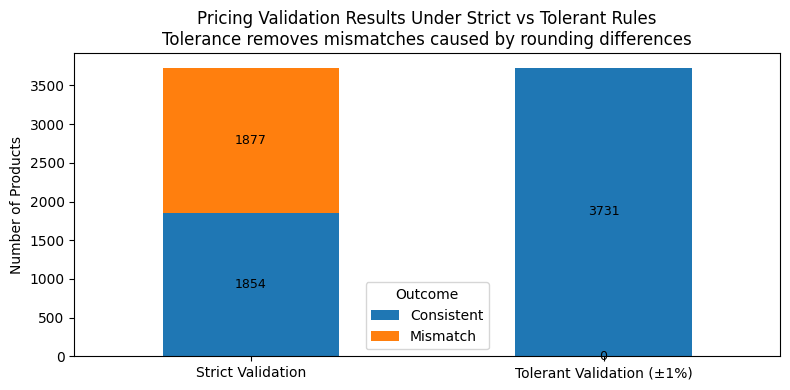

In [5]:
# Plot pricing validation comparison (rule-based view)

import matplotlib.pyplot as plt

# Reshape data to compare validation rules
plot_df = (
    comparison_df
    .set_index('Outcome')   # FIXED: Outcome, not Check
    .T
    .reset_index()
    .rename(columns={'index': 'Rule'})
)

# Improve rule labels for clarity
plot_df['Rule'] = plot_df['Rule'].replace({
    'Strict': 'Strict Validation',
    'Tolerant': 'Tolerant Validation (±1%)'
})

# Stacked bar chart
ax = plot_df.plot(
    kind='bar',
    x='Rule',
    y=['Consistent', 'Mismatch'],
    stacked=True,
    figsize=(8, 4)
)

# Titles & labels
plt.title(
    "Pricing Validation Results Under Strict vs Tolerant Rules\n"
    "Tolerance removes mismatches caused by rounding differences"
)
plt.ylabel("Number of Products")
plt.xlabel("")
plt.xticks(rotation=0)

# Add value labels inside bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9)

plt.tight_layout()
plt.savefig("images/pricing_validation_rules_comparison.png")
plt.show()


## Inventory Risk Analysis

This section analyzes potential revenue loss caused by out-of-stock products,
aggregated at the category level.

In [6]:
# Load inventory risk data from SQL view
inventory_df = pd.read_sql(
    "SELECT * FROM inventory_risk;",
    engine
)

print(f"Rows in inventory risk view: {inventory_df.shape[0]}")
inventory_df.head()

Rows in inventory risk view: 9


,category,out_of_stock_items,total_available,potential_loss
0,Chocolates & Candies,41,4726,13280.0
1,Cooking Essentials,50,3900,9812.0
2,Beverages,27,1394,5153.0
3,Paan Corner,14,2688,3388.0
4,Health & Hygiene,13,658,2582.0


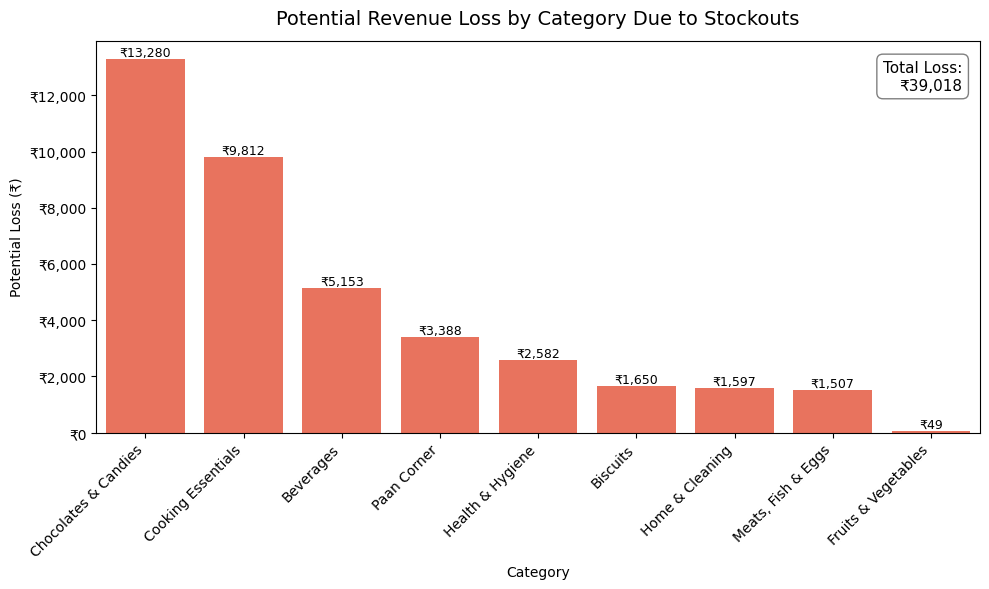

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Sort categories by potential loss
inventory_df_sorted = inventory_df.sort_values(
    by="potential_loss", ascending=False
)

# Calculate total potential loss
total_loss = inventory_df["potential_loss"].sum()

plt.figure(figsize=(10, 6))

# Vertical bar chart
ax = sns.barplot(
    data=inventory_df_sorted,
    x="category",
    y="potential_loss",
    color="tomato"
)

ax.text(
    0.98, 0.95,
    f"Total Loss:\n₹{int(total_loss):,}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray")
)

# Titles and labels
plt.title(
    f"Potential Revenue Loss by Category Due to Stockouts",
    fontsize=14,
    pad=12
)

plt.xlabel("Category")
plt.ylabel("Potential Loss (₹)")

# Rotate x labels for readability
plt.xticks(rotation=45, ha="right")

# Format Y-axis as Rupees (no lakhs)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"₹{int(x):,}")
)

# Add value labels on top of bars (skip zero values)
for p in ax.patches:
    value = p.get_height()
    if value > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            value,
            f"₹{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("images/inventory_risk_with_labels.png")
plt.show()


## Revenue Opportunity Analysis

This section compares actual revenue against potential revenue
to identify categories where pricing or discount optimization
could increase overall revenue.

In [9]:
# Load revenue opportunity data from SQL view
revenue_df = pd.read_sql(
    "SELECT * FROM revenue_opportunity;",
    engine
)

print(f"Rows in revenue opportunity view: {revenue_df.shape[0]}")
revenue_df.head()

Rows in revenue opportunity view: 9


,category,actual_revenue,potential_revenue,discount_cost
0,Chocolates & Candies,689782.0,768889.0,79107.0
1,Cooking Essentials,619004.0,695053.0,76049.0
2,Paan Corner,502558.0,549030.0,46472.0
3,Beverages,160785.0,184345.0,23560.0
4,Home & Cleaning,122133.0,131772.0,9639.0


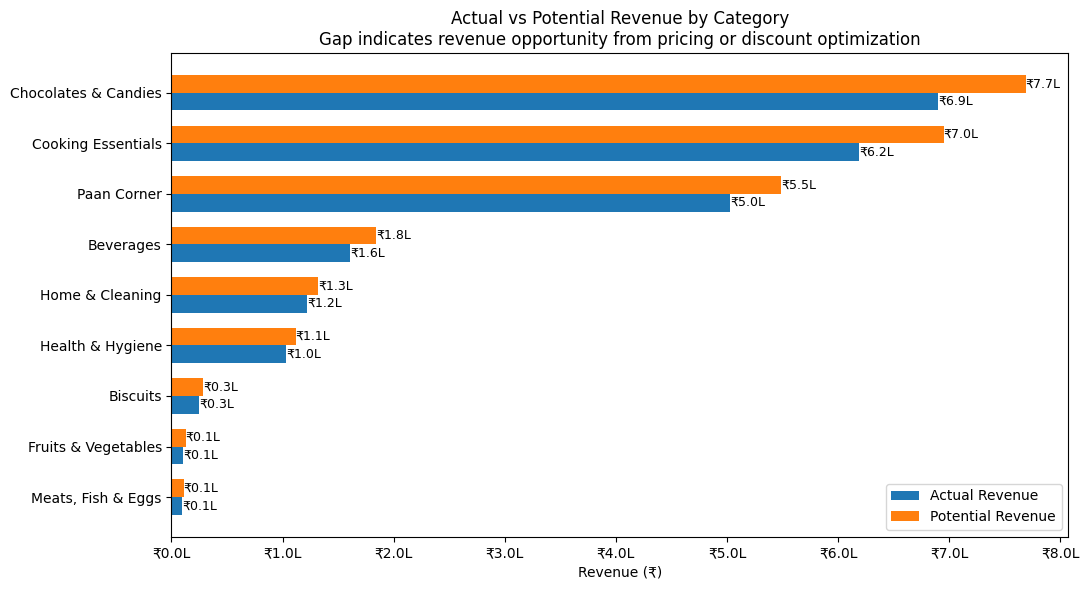

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Calculate revenue gap
revenue_df["revenue_gap"] = (
    revenue_df["potential_revenue"] - revenue_df["actual_revenue"]
)

# Sort by revenue gap (highest opportunity at top)
revenue_df_sorted = revenue_df.sort_values(
    by="revenue_gap", ascending=True
)

# Y positions
y = np.arange(len(revenue_df_sorted))
bar_height = 0.35

plt.figure(figsize=(11, 6))

# Actual Revenue
plt.barh(
    y - bar_height / 2,
    revenue_df_sorted["actual_revenue"],
    height=bar_height,
    label="Actual Revenue"
)

# Potential Revenue
plt.barh(
    y + bar_height / 2,
    revenue_df_sorted["potential_revenue"],
    height=bar_height,
    label="Potential Revenue"
)

# Axis labels
plt.yticks(y, revenue_df_sorted["category"])
plt.xlabel("Revenue (₹)")
plt.title(
    "Actual vs Potential Revenue by Category\n"
    "Gap indicates revenue opportunity from pricing or discount optimization"
)

# Format x-axis in Lakhs
plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"₹{x/100000:.1f}L")
)

# Add value labels
for idx, row in enumerate(revenue_df_sorted.itertuples()):
    plt.text(
        row.actual_revenue,
        idx - bar_height / 2,
        f"₹{row.actual_revenue/100000:.1f}L",
        va="center",
        ha="left",
        fontsize=9
    )
    plt.text(
        row.potential_revenue,
        idx + bar_height / 2,
        f"₹{row.potential_revenue/100000:.1f}L",
        va="center",
        ha="left",
        fontsize=9
    )

plt.legend()
plt.tight_layout()
plt.savefig("images/revenue_actual_vs_potential.png")
plt.show()
